# AEGIS notebook

Project: AEGIS rebuild for reproducible wind anomaly, federated learning, and edge deployment evaluation.


# 02_baselines

Purpose: rebuild baseline anomaly detectors for wind SCADA anomaly detection using the same core event setup as the main project, then save all metrics, confusion matrices, and comparison plots in a reproducible structure.

Outputs:
- `results/02_baseline_results.csv`
- `tables/02_baseline_results.csv`
- `results/02_baseline_split_summary.csv`
- `results/02_event_file_matches.csv`
- `results/02_loaded_event_shapes.csv`
- `data/processed/02_baseline_combined_dataset.csv`
- `figures/02_baseline_comparison.png`
- `figures/02_confusion_matrix_isolationforest.png`
- `figures/02_confusion_matrix_oneclasssvm.png`
- `figures/02_confusion_matrix_localoutlierfactor.png`

In [17]:
from pathlib import Path
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix
)

SEED = 42
np.random.seed(SEED)

ROOT = Path.cwd()
RAW_DIR = ROOT / "data" / "raw"
WIND_DIR = ROOT / "data" / "Wind Farm A" / "datasets"
PROCESSED_DIR = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures"
TABLES_DIR = ROOT / "tables"

for d in [PROCESSED_DIR, MODELS_DIR, RESULTS_DIR, FIGURES_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Raw data folder exists:", RAW_DIR.exists())
print("Wind event folder exists:", WIND_DIR.exists())
print("Results folder:", RESULTS_DIR)
print("Figures folder:", FIGURES_DIR)
print("Tables folder:", TABLES_DIR)

Project root: C:\Users\MOINODHEEN\Moinu\Aegis_Project
Raw data folder exists: True
Wind event folder exists: True
Results folder: C:\Users\MOINODHEEN\Moinu\Aegis_Project\results
Figures folder: C:\Users\MOINODHEEN\Moinu\Aegis_Project\figures
Tables folder: C:\Users\MOINODHEEN\Moinu\Aegis_Project\tables


In [18]:
EVENT_ROLE_MAP = {
    25: 0,   # normal
    69: 0,   # normal
    68: 1,   # anomaly
    22: 1    # anomaly
}

EVENT_NAME_MAP = {
    25: "event_25_normal",
    69: "event_69_normal",
    68: "event_68_anomaly",
    22: "event_22_anomaly"
}

MANUAL_WIND_EVENT_FILES = {
    25: WIND_DIR / "25.csv",
    69: WIND_DIR / "69.csv",
    68: WIND_DIR / "68.csv",
    22: WIND_DIR / "22.csv"
}

selected_files = {}
match_rows = []

for event_id in EVENT_ROLE_MAP:
    p = MANUAL_WIND_EVENT_FILES[event_id]

    if not p.exists():
        raise FileNotFoundError(f"Manual file for event {event_id} not found: {p}")

    selected_files[event_id] = p
    match_rows.append({
        "event_id": event_id,
        "event_name": EVENT_NAME_MAP[event_id],
        "role": "normal" if EVENT_ROLE_MAP[event_id] == 0 else "anomaly",
        "selected_file": str(p),
        "match_type": "manual_locked"
    })

match_df = pd.DataFrame(match_rows).sort_values("event_id").reset_index(drop=True)
display(match_df)

match_df.to_csv(RESULTS_DIR / "02_event_file_matches.csv", index=False)
match_df.to_csv(TABLES_DIR / "02_event_file_matches.csv", index=False)

print("Saved:")
print(RESULTS_DIR / "02_event_file_matches.csv")
print(TABLES_DIR / "02_event_file_matches.csv")

,event_id,event_name,role,selected_file,match_type
0,22,event_22_anomaly,anomaly,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,manual_locked
1,25,event_25_normal,normal,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,manual_locked
2,68,event_68_anomaly,anomaly,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,manual_locked
3,69,event_69_normal,normal,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,manual_locked


Saved:
C:\Users\MOINODHEEN\Moinu\Aegis_Project\results\02_event_file_matches.csv
C:\Users\MOINODHEEN\Moinu\Aegis_Project\tables\02_event_file_matches.csv


In [23]:
drop_exact = {"asset_id", "assetid", "id", "status_type_id", "statustypeid"}

event_frames = {}
raw_shapes = []

for event_id, file_path in selected_files.items():
    df = pd.read_csv(file_path, sep=';', low_memory=False)
    df.columns = df.columns.str.strip()

    num_df = df.select_dtypes(include=[np.number]).copy()
    num_df = num_df.loc[:, num_df.notna().any()]

    keep_cols = [c for c in num_df.columns if c.strip().lower() not in drop_exact]
    num_df = num_df[keep_cols].copy()

    raw_shapes.append({
        "event_id": event_id,
        "event_name": EVENT_NAME_MAP[event_id],
        "raw_rows": int(df.shape[0]),
        "raw_cols": int(df.shape[1]),
        "numeric_rows": int(num_df.shape[0]),
        "numeric_cols": int(num_df.shape[1]),
        "file_name": file_path.name
    })

    event_frames[event_id] = num_df

shape_df = pd.DataFrame(raw_shapes).sort_values("event_id").reset_index(drop=True)
display(shape_df)

min_feature_count = min(df.shape[1] for df in event_frames.values())
if min_feature_count == 0:
    raise ValueError("No usable numeric sensor columns found after cleaning.")

feature_cols = [f"feature_{i:03d}" for i in range(min_feature_count)]

assembled = []
for event_id, df in event_frames.items():
    part = df.iloc[:, :min_feature_count].copy()
    part.columns = feature_cols
    part["label"] = EVENT_ROLE_MAP[event_id]
    part["source_event"] = event_id
    assembled.append(part)

full_df = pd.concat(assembled, ignore_index=True)
full_df = full_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Combined dataset shape:", full_df.shape)
print("Aligned feature count:", len(feature_cols))
print("Class counts:\n", full_df["label"].value_counts().sort_index())
print("Per-event numeric column counts:", {k: v.shape[1] for k, v in event_frames.items()})

shape_df.to_csv(RESULTS_DIR / "02_loaded_event_shapes.csv", index=False)
shape_df.to_csv(TABLES_DIR / "02_loaded_event_shapes.csv", index=False)
full_df.to_csv(PROCESSED_DIR / "02_baseline_combined_dataset.csv", index=False)

,event_id,event_name,raw_rows,raw_cols,numeric_rows,numeric_cols,file_name
0,22,event_22_anomaly,53036,86,53036,81,22.csv
1,25,event_25_normal,54712,86,54712,81,25.csv
2,68,event_68_anomaly,54358,86,54358,81,68.csv
3,69,event_69_normal,54813,86,54813,81,69.csv


Combined dataset shape: (216919, 83)
Aligned feature count: 81
Class counts:
 label
0    109525
1    107394
Name: count, dtype: int64
Per-event numeric column counts: {25: 81, 69: 81, 68: 81, 22: 81}


In [24]:
X = full_df[feature_cols].copy()
y = full_df["label"].astype(int).copy()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

X_train_normal = X_train_full[y_train_full == 0].copy()

train_medians = X_train_normal.median(numeric_only=True).fillna(0)
X_train_normal = X_train_normal.fillna(train_medians)
X_test = X_test.fillna(train_medians)

scaler = StandardScaler()
X_train_normal_scaled = scaler.fit_transform(X_train_normal)
X_test_scaled = scaler.transform(X_test)

split_summary = pd.DataFrame([{
    "total_rows": int(len(full_df)),
    "feature_count": int(len(feature_cols)),
    "train_full_rows": int(len(X_train_full)),
    "train_normal_rows": int(len(X_train_normal)),
    "test_rows": int(len(X_test)),
    "test_normal_rows": int((y_test == 0).sum()),
    "test_anomaly_rows": int((y_test == 1).sum())
}])

display(split_summary)

split_summary.to_csv(RESULTS_DIR / "02_baseline_split_summary.csv", index=False)
split_summary.to_csv(TABLES_DIR / "02_baseline_split_summary.csv", index=False)

,total_rows,feature_count,train_full_rows,train_normal_rows,test_rows,test_normal_rows,test_anomaly_rows
0,216919,81,173535,87620,43384,21905,21479


In [25]:
def anomaly_metrics(y_true, y_pred, scores, model_name, fit_seconds, train_rows):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "model": model_name,
        "train_rows_used": int(train_rows),
        "fit_time_seconds": round(float(fit_seconds), 4),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 4),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 4),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 4),
        "roc_auc": round(float(roc_auc_score(y_true, scores)), 4),
        "pr_auc": round(float(average_precision_score(y_true, scores)), 4),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "predicted_anomalies": int(np.sum(y_pred == 1))
    }

rng = np.random.default_rng(SEED)

def sample_rows(X_arr, n):
    if len(X_arr) <= n:
        return X_arr
    idx = rng.choice(len(X_arr), size=n, replace=False)
    return X_arr[idx]

X_train_if = X_train_normal_scaled
X_train_ocsvm = sample_rows(X_train_normal_scaled, 15000)
X_train_lof = sample_rows(X_train_normal_scaled, 20000)

models = {
    "IsolationForest": IsolationForest(
        n_estimators=100,
        contamination=0.10,
        random_state=SEED,
        n_jobs=-1
    ),
    "OneClassSVM": OneClassSVM(
        kernel="rbf",
        gamma="scale",
        nu=0.10
    ),
    "LocalOutlierFactor": LocalOutlierFactor(
        n_neighbors=35,
        contamination=0.10,
        novelty=True
    )
}

train_sets = {
    "IsolationForest": X_train_if,
    "OneClassSVM": X_train_ocsvm,
    "LocalOutlierFactor": X_train_lof
}

results = []
pred_store = {}

for name, model in models.items():
    X_train_used = train_sets[name]
    t0 = time.time()
    model.fit(X_train_used)
    fit_seconds = time.time() - t0

    raw_pred = model.predict(X_test_scaled)
    y_pred = np.where(raw_pred == -1, 1, 0)

    scores = -model.decision_function(X_test_scaled)

    results.append(
        anomaly_metrics(
            y_true=y_test.values,
            y_pred=y_pred,
            scores=scores,
            model_name=name,
            fit_seconds=fit_seconds,
            train_rows=len(X_train_used)
        )
    )

    pred_store[name] = {
        "y_pred": y_pred,
        "scores": scores
    }

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False).reset_index(drop=True)
display(results_df)

results_df.to_csv(RESULTS_DIR / "02_baseline_results.csv", index=False)
results_df.to_csv(TABLES_DIR / "02_baseline_results.csv", index=False)

,model,train_rows_used,fit_time_seconds,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,predicted_anomalies
0,LocalOutlierFactor,20000,11.8141,0.8182,0.4498,0.5805,0.7149,0.7458,19758,2147,11817,9662,11809
1,OneClassSVM,15000,4.4725,0.6844,0.2229,0.3362,0.6373,0.6111,19698,2207,16692,4787,6994
2,IsolationForest,87620,1.9937,0.5780,0.1413,0.2271,0.5833,0.5522,19688,2217,18443,3036,5253


In [26]:
def slugify(name):
    return name.lower().replace(" ", "")

for name in pred_store:
    y_pred = pred_store[name]["y_pred"]
    cm = confusion_matrix(y_test.values, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{name} confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"02_confusion_matrix_{slugify(name)}.png", dpi=300, bbox_inches="tight")
    plt.close()

print("Saved confusion matrix PNG files to:", FIGURES_DIR)

Saved confusion matrix PNG files to: C:\Users\MOINODHEEN\Moinu\Aegis_Project\figures


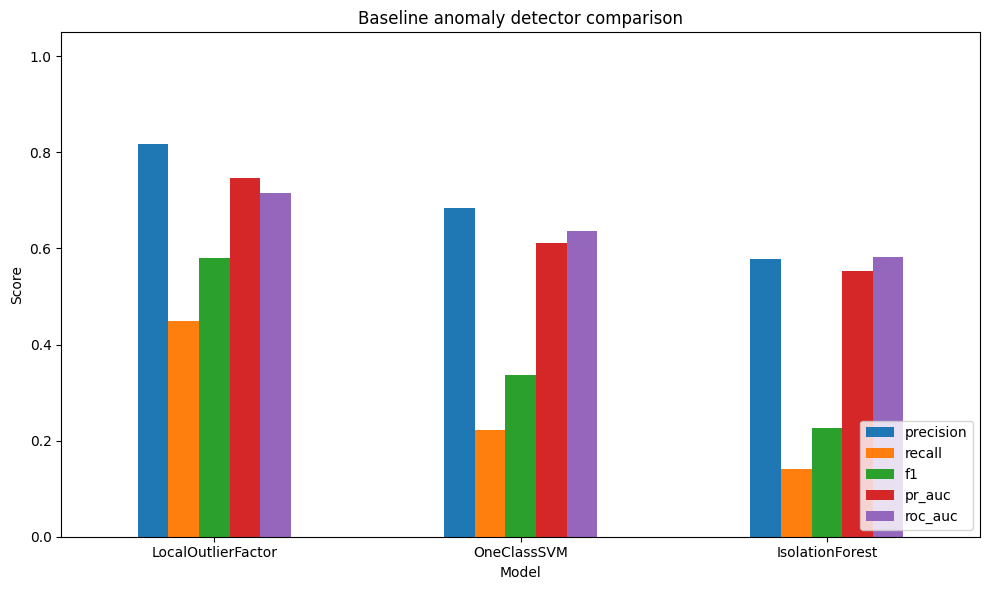

In [27]:
plot_df = results_df.set_index("model")[["precision", "recall", "f1", "pr_auc", "roc_auc"]]

ax = plot_df.plot(kind="bar", figsize=(10, 6))
ax.set_title("Baseline anomaly detector comparison")
ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_baseline_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [28]:
artifact_list = sorted([
    str(p.relative_to(ROOT))
    for p in list(RESULTS_DIR.glob("02_*")) + list(TABLES_DIR.glob("02_*")) + list(FIGURES_DIR.glob("02_*"))
])

final_summary = {
    "notebook": "02_baselines.ipynb",
    "artifacts_created": artifact_list,
    "best_model_by_f1": results_df.iloc[0]["model"],
    "best_f1": float(results_df.iloc[0]["f1"]),
    "timestamp": pd.Timestamp.now().isoformat()
}

print(json.dumps(final_summary, indent=2))

{
  "notebook": "02_baselines.ipynb",
  "artifacts_created": [
    "figures\\02_baseline_comparison.png",
    "figures\\02_confusion_matrix_isolationforest.png",
    "figures\\02_confusion_matrix_localoutlierfactor.png",
    "figures\\02_confusion_matrix_oneclasssvm.png",
    "results\\02_baseline_results.csv",
    "results\\02_baseline_split_summary.csv",
    "results\\02_event_file_matches.csv",
    "results\\02_loaded_event_shapes.csv",
    "tables\\02_baseline_results.csv",
    "tables\\02_baseline_split_summary.csv",
    "tables\\02_event_file_matches.csv",
    "tables\\02_loaded_event_shapes.csv"
  ],
  "best_model_by_f1": "LocalOutlierFactor",
  "best_f1": 0.5805,
  "timestamp": "2026-04-02T22:34:19.525267"
}
